# MEMUAT DATA

In [87]:
import pandas as pd

df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


# EKSPLORASI DATA

In [88]:
# Cek jumlah data

print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah data: 3276
Jumlah kolom: 10


In [89]:
# Cek jumlah tiap kelas

# Jumlah dan persentase tiap kelas
jumlah = df['Potability'].value_counts().sort_index()
persen = df['Potability'].value_counts(normalize=True).sort_index() * 100

hasil = pd.DataFrame({"Jumlah": jumlah, "Persen (%)": persen.round(2)})
hasil.index = ["Tidak layak minum (0)", "Layak minum (1)"]
hasil

,Jumlah,Persen (%)
Tidak layak minum (0),1998,60.99
Layak minum (1),1278,39.01


In [90]:
# Cek missing value
print("Jumlah missing value:")
df.isnull().sum()

Jumlah missing value:


,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [91]:
# Cek data duplikat
print("Jumlah data duplikat:" )
df.duplicated().sum()

Jumlah data duplikat:


np.int64(0)

# PEMBAGIAN DATA

In [92]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns="Potability")
y = df["Potability"]

# Bagi data: 80% latih, 20% uji
X_latih, X_uji, y_latih, y_uji = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Cek hasil pembagian
print("Data latih:", X_latih.shape[0], "baris")
print("Data uji  :", X_uji.shape[0], "baris")

Data latih: 2620 baris
Data uji  : 656 baris


In [93]:
# Cek proporsi kelas di data latih dan data uji
ringkasan = pd.DataFrame({
    "Data latih": y_latih.value_counts().sort_index(),
    "Persen latih (%)": (y_latih.value_counts(normalize=True).sort_index() * 100).round(2),
    "Data uji": y_uji.value_counts().sort_index(),
    "Persen uji (%)": (y_uji.value_counts(normalize=True).sort_index() * 100).round(2),
})
ringkasan.index = ["Tidak layak minum (0)", "Layak minum (1)"]
ringkasan

,Data latih,Persen latih (%),Data uji,Persen uji (%)
Tidak layak minum (0),1598,60.99,400,60.98
Layak minum (1),1022,39.01,256,39.02


# VISUALISASI DATA

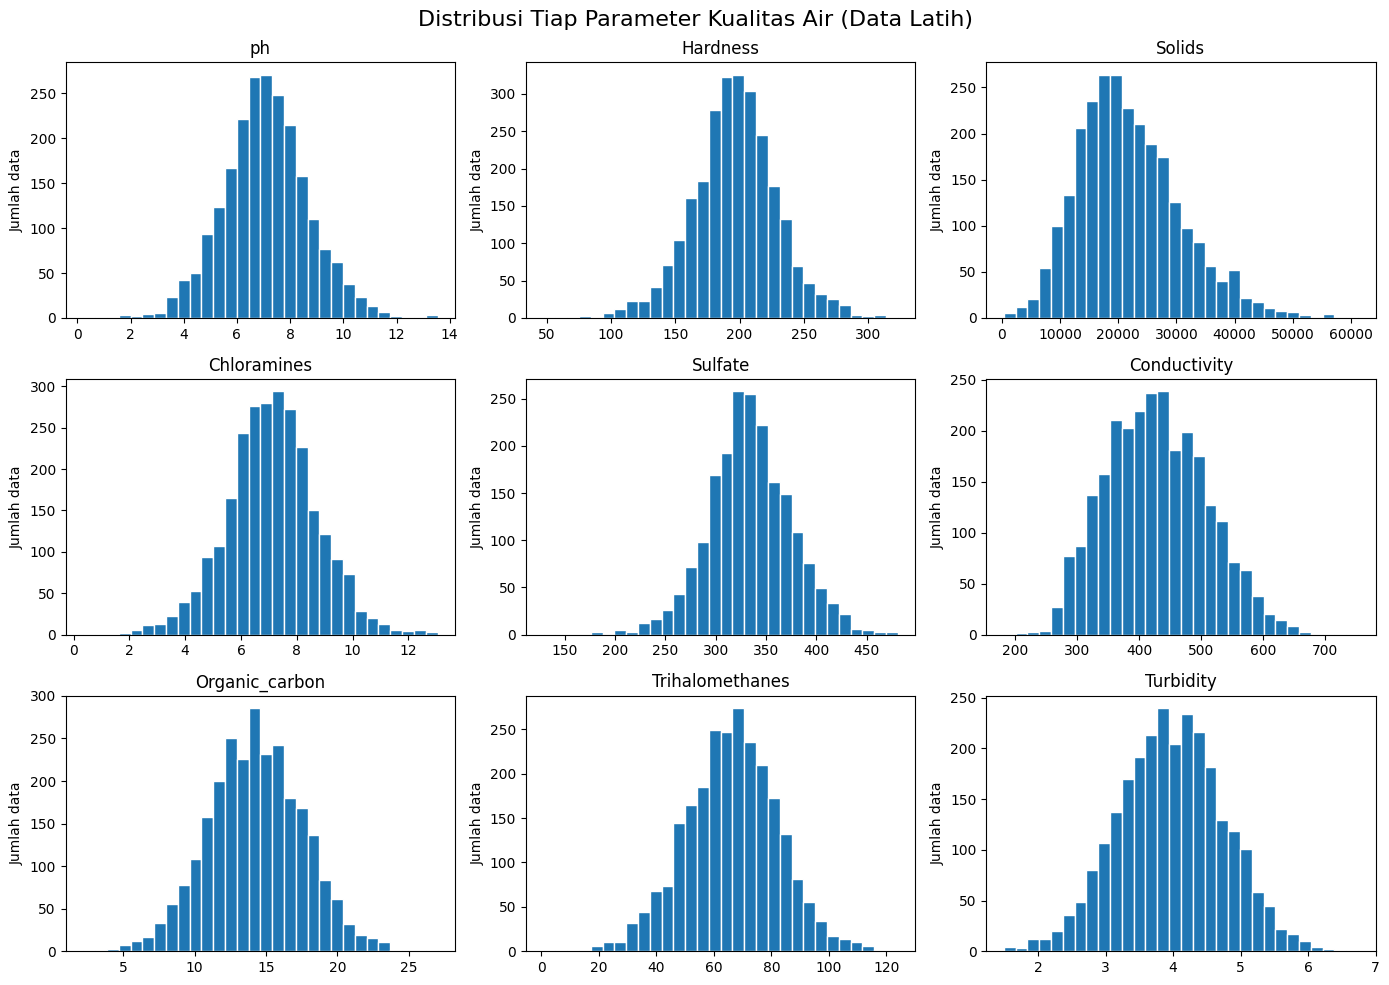

In [94]:
import matplotlib.pyplot as plt

fitur = X_latih.columns

# Histogram tiap parameter (nilai kosong diabaikan)
fig, sumbu = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Distribusi Tiap Parameter Kualitas Air (Data Latih)", fontsize=16)

for ax, kolom in zip(sumbu.flat, fitur):
    ax.hist(X_latih[kolom].dropna(), bins=30, color="tab:blue", edgecolor="white")
    ax.set_title(kolom)
    ax.set_ylabel("Jumlah data")

plt.tight_layout()
plt.show()

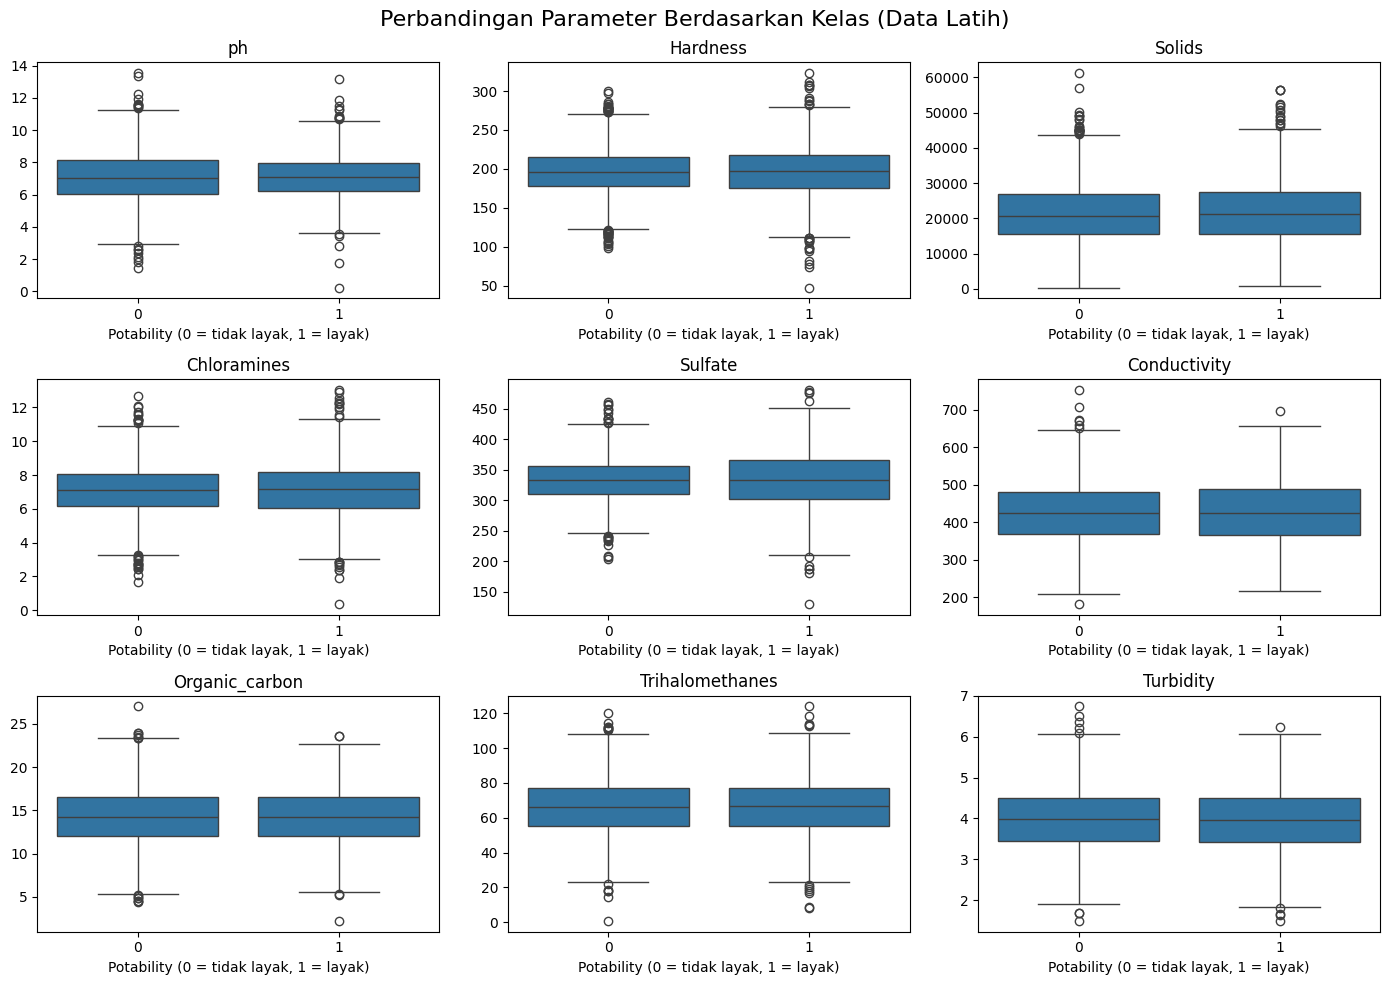

In [95]:
import seaborn as sns

# Boxplot tiap parameter, dipisah menurut kelas
fig, sumbu = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Perbandingan Parameter Berdasarkan Kelas (Data Latih)", fontsize=16)

for ax, kolom in zip(sumbu.flat, fitur):
    sns.boxplot(x=y_latih, y=X_latih[kolom], ax=ax)
    ax.set_title(kolom)
    ax.set_xlabel("Potability (0 = tidak layak, 1 = layak)")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

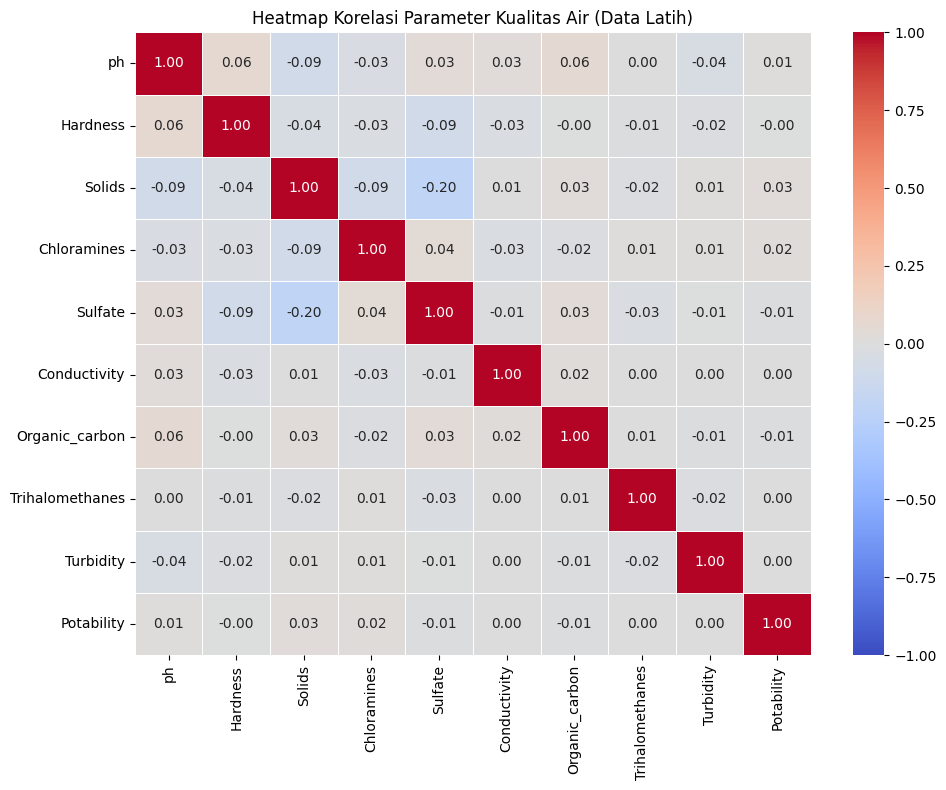

In [96]:
# Gabungkan fitur dan target, lalu hitung korelasi

data_latih = X_latih.copy()
data_latih["Potability"] = y_latih
korelasi = data_latih.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    korelasi,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Heatmap Korelasi Parameter Kualitas Air (Data Latih)")
plt.tight_layout()
plt.show()

# PREPROCESSING

In [97]:
# Simpan salinan data latih sebelum nilai kosong diisi (untuk perbandingan)
X_latih_awal = X_latih.copy()

# Cek nilai kosong pada data latih dan data uji
print("Nilai kosong data latih:", X_latih.isnull().sum().sum())
print("Nilai kosong data uji  :", X_uji.isnull().sum().sum())

Nilai kosong data latih: 1146
Nilai kosong data uji  : 288


In [98]:
# Isi missing value dengan median

# Hitung median dari data latih saja
median_latih = X_latih.median()

# Isi nilai kosong di data latih dan data uji dengan median yang sama
X_latih = X_latih.fillna(median_latih)
X_uji = X_uji.fillna(median_latih)

# Cek kembali
print("Nilai kosong data latih setelah diisi:", X_latih.isnull().sum().sum())
print("Nilai kosong data uji setelah diisi  :", X_uji.isnull().sum().sum())

Nilai kosong data latih setelah diisi: 0
Nilai kosong data uji setelah diisi  : 0


In [99]:
# Tabel Perbandingan Sebelum dan Sesudah isi Missing Value

# Jumlah nilai kosong data latih sebelum dan sesudah diisi
perbandingan = pd.DataFrame({
    "Sebelum": X_latih_awal.isnull().sum(),
    "Sesudah": X_latih.isnull().sum()
})

# Tampilkan hanya kolom yang berubah
perbandingan = perbandingan[perbandingan["Sebelum"] != perbandingan["Sesudah"]]
perbandingan

,Sebelum,Sesudah
ph,387,0
Sulfate,625,0
Trihalomethanes,134,0


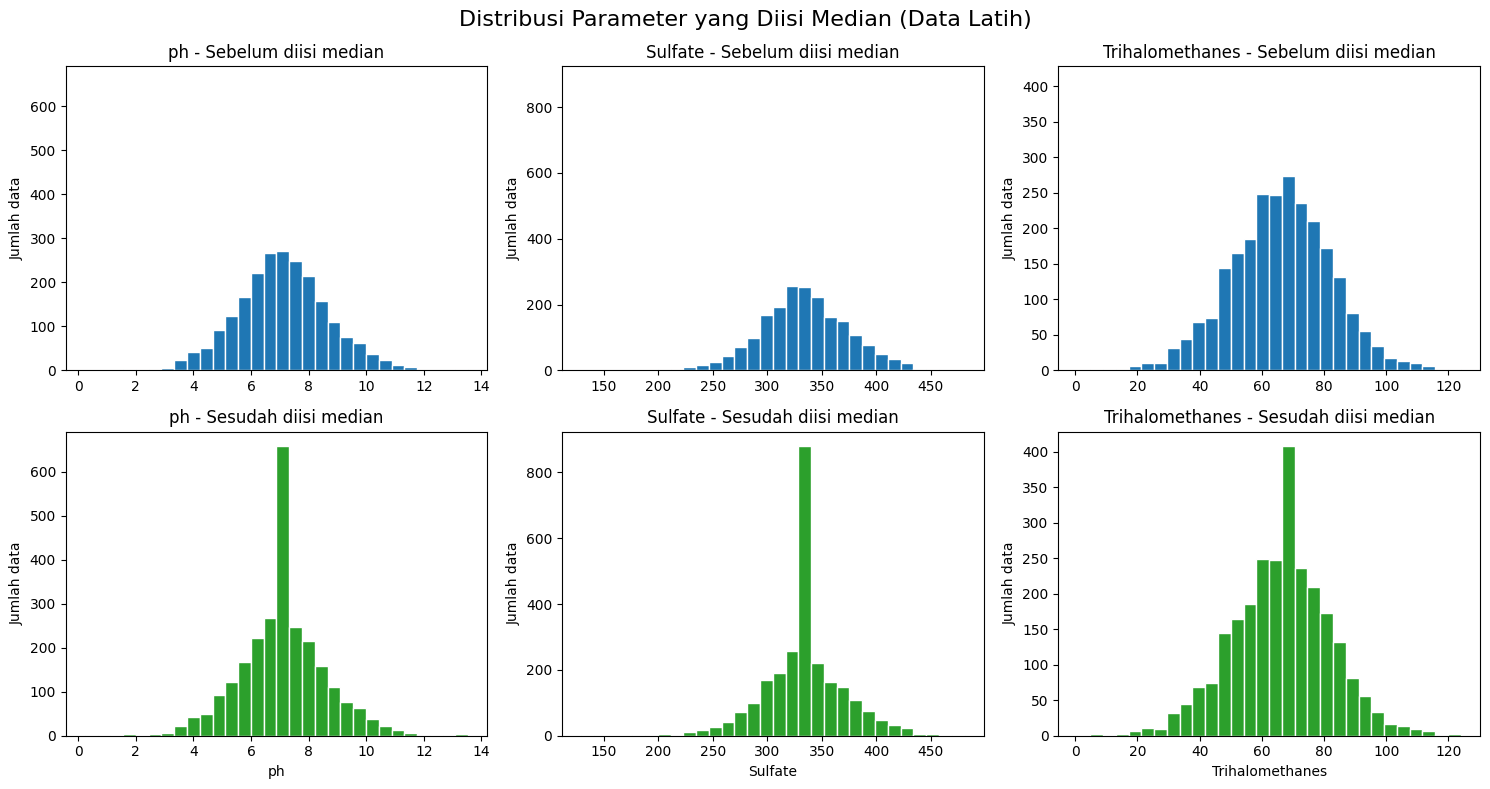

In [100]:
# Distribusi kolom yang diisi: baris atas = sebelum, baris bawah = sesudah
kolom_diisi = perbandingan.index

fig, sumbu = plt.subplots(2, 3, figsize=(15, 8), sharey="col")
fig.suptitle("Distribusi Parameter yang Diisi Median (Data Latih)", fontsize=16)

for i, kolom in enumerate(kolom_diisi):
    # Sebelum
    sumbu[0, i].hist(X_latih_awal[kolom].dropna(), bins=30, color="tab:blue", edgecolor="white")
    sumbu[0, i].set_title(f"{kolom} - Sebelum diisi median")
    sumbu[0, i].set_ylabel("Jumlah data")

    # Sesudah
    sumbu[1, i].hist(X_latih[kolom], bins=30, color="tab:green", edgecolor="white")
    sumbu[1, i].set_title(f"{kolom} - Sesudah diisi median")
    sumbu[1, i].set_xlabel(kolom)
    sumbu[1, i].set_ylabel("Jumlah data")

plt.tight_layout()
plt.show()

In [101]:
# Standarisasi Skala

from sklearn.preprocessing import StandardScaler

standarisasi = StandardScaler()

# Hitung rata-rata dan simpangan baku dari data latih, lalu terapkan ke data latih
X_latih_std = pd.DataFrame(
    standarisasi.fit_transform(X_latih),
    columns=X_latih.columns, index=X_latih.index
)

# Data uji hanya diterapkan (transform), memakai angka dari data latih
X_uji_std = pd.DataFrame(
    standarisasi.transform(X_uji),
    columns=X_uji.columns, index=X_uji.index
)

# Bandingkan skala data latih sebelum dan sesudah standarisasi
pd.DataFrame({
    "Rata-rata sebelum": X_latih.mean().round(2),
    "Simpangan baku sebelum": X_latih.std().round(2),
    "Rata-rata sesudah": X_latih_std.mean().round(2),
    "Simpangan baku sesudah": X_latih_std.std().round(2),
})

,Rata-rata sebelum,Simpangan baku sebelum,Rata-rata sesudah,Simpangan baku sesudah
ph,7.08,1.47,0.0,1.0
Hardness,196.52,32.64,-0.0,1.0
Solids,21888.07,8760.11,0.0,1.0
Chloramines,7.12,1.60,0.0,1.0
Sulfate,333.77,36.24,0.0,1.0
Conductivity,427.92,80.94,0.0,1.0
Organic_carbon,14.27,3.30,-0.0,1.0
Trihalomethanes,66.16,15.80,-0.0,1.0
Turbidity,3.97,0.78,-0.0,1.0


# TRAINING MODEL

In [102]:
# Model pembanding: selalu menebak kelas yang paling banyak (0)
from sklearn.dummy import DummyClassifier

model_dummy = DummyClassifier(strategy="most_frequent")
model_dummy.fit(X_latih_std, y_latih)

DummyClassifier(strategy='most_frequent')

In [103]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_latih_std, y_latih)

LogisticRegression(max_iter=1000, random_state=42)

In [104]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_latih_std, y_latih)

RandomForestClassifier(random_state=42)

In [105]:
# Bandingkan akurasi data latih dan data uji
from sklearn.metrics import accuracy_score

daftar_model = {
    "Dummy (pembanding)": model_dummy,
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
}

hasil_akurasi = pd.DataFrame({
    "Akurasi latih": {n: accuracy_score(y_latih, m.predict(X_latih_std)) for n, m in daftar_model.items()},
    "Akurasi uji": {n: accuracy_score(y_uji, m.predict(X_uji_std)) for n, m in daftar_model.items()},
}).round(3)

# Selisih besar = tanda overfitting
hasil_akurasi["Selisih"] = (hasil_akurasi["Akurasi latih"] - hasil_akurasi["Akurasi uji"]).round(3)
hasil_akurasi

,Akurasi latih,Akurasi uji,Selisih
Dummy (pembanding),0.61,0.610,0.000
Logistic Regression,0.61,0.610,0.000
Random Forest,1.00,0.663,0.337


**Catatan Hasil Training Model**

- **Dummy (pembanding):** akurasi 61% pada data latih maupun data uji. Model ini hanya menebak "tidak layak minum" untuk semua data, sehingga angka ini menjadi patokan minimal yang harus dikalahkan model lain.
- **Logistic Regression:** akurasi 61%, sama persis dengan Dummy. Artinya model ini belum lebih baik daripada menebak kelas mayoritas. Dugaan sementara, model hanya memprediksi kelas 0. Dugaan ini akan dibuktikan dengan confusion matrix pada bagian evaluasi.
- **Random Forest:** akurasi latih 100% dan akurasi uji 66,3%. Hasil ini sedikit lebih baik dari Dummy (sekitar 5 poin), tetapi selisih 33,7 poin antara data latih dan data uji menunjukkan **overfitting**: model menghafal data latih, bukan mempelajari pola yang berlaku umum.
- **Kesimpulan sementara:** akurasi saja belum cukup untuk menilai model, apalagi kelasnya tidak seimbang (61% : 39%). Evaluasi berikutnya memakai precision, recall, F1-score, dan confusion matrix.

# EVALUASI MODEL

Kelas "Layak minum (1)" dianggap sebagai kelas positif.

- **Akurasi**: persentase seluruh tebakan yang benar.
- **Precision**: dari semua air yang diprediksi layak, berapa persen yang benar-benar layak.
- **Recall**: dari semua air yang benar-benar layak, berapa persen yang berhasil ditemukan model.
- **F1-score**: gabungan precision dan recall.
- **ROC-AUC**: kemampuan model membedakan dua kelas (0,5 = sama dengan menebak acak, 1 = sempurna).

In [106]:
# Prediksi tiap model pada data uji
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

prediksi_uji = {nama: model.predict(X_uji_std) for nama, model in daftar_model.items()}

In [107]:
# Tabel perbandingan metrik pada data uji
hasil_evaluasi = pd.DataFrame({
    "Akurasi": {n: accuracy_score(y_uji, p) for n, p in prediksi_uji.items()},
    "Precision": {n: precision_score(y_uji, p, zero_division=0) for n, p in prediksi_uji.items()},
    "Recall": {n: recall_score(y_uji, p) for n, p in prediksi_uji.items()},
    "F1-score": {n: f1_score(y_uji, p) for n, p in prediksi_uji.items()},
    "ROC-AUC": {n: roc_auc_score(y_uji, m.predict_proba(X_uji_std)[:, 1]) for n, m in daftar_model.items()},
}).round(3)

hasil_evaluasi

,Akurasi,Precision,Recall,F1-score,ROC-AUC
Dummy (pembanding),0.610,0.000,0.000,0.000,0.500
Logistic Regression,0.610,0.000,0.000,0.000,0.548
Random Forest,0.663,0.645,0.305,0.414,0.641


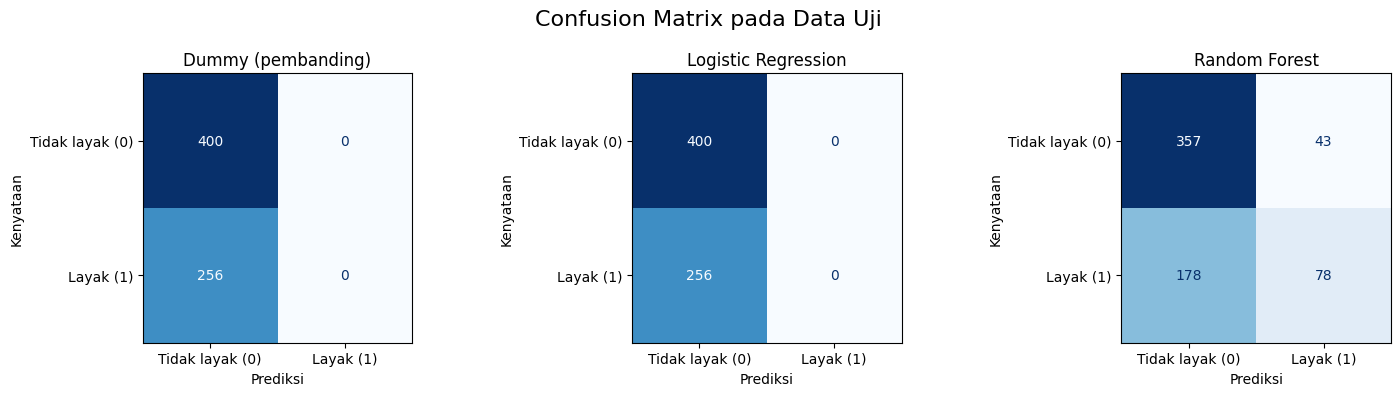

In [108]:
# Confusion matrix tiap model pada data uji
from sklearn.metrics import ConfusionMatrixDisplay

fig, sumbu = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Confusion Matrix pada Data Uji", fontsize=16)

for ax, (nama, prediksi) in zip(sumbu, prediksi_uji.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_uji, prediksi,
        display_labels=["Tidak layak (0)", "Layak (1)"],
        cmap="Blues", colorbar=False, ax=ax
    )
    ax.set_title(nama)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Kenyataan")

plt.tight_layout()
plt.show()

**Catatan Hasil Evaluasi Model**

- **Dummy dan Logistic Regression:** keduanya memprediksi semua data sebagai "tidak layak" (400 benar, 256 salah). Precision, recall, dan F1-score bernilai 0, sehingga akurasi 61% tidak berarti model bisa mengenali air layak minum. Ini membuktikan dugaan sebelumnya bahwa Logistic Regression bawaan hanya menebak kelas mayoritas.
- **Random Forest:** akurasi 66,3%, precision 64,5%, recall 30,5%, F1-score 41,4%, dan ROC-AUC 0,641. Dari 256 air yang benar-benar layak, hanya 78 yang berhasil ditemukan (178 terlewat).
- **Kesalahan paling berbahaya:** 43 sampel air tidak layak diprediksi layak oleh Random Forest (sekitar 10,8% dari seluruh air tidak layak). Pada kasus nyata, kesalahan jenis ini berisiko bagi kesehatan.
- **Kesimpulan sementara:** Random Forest satu-satunya model yang mulai mengenali kelas layak minum, tetapi recall-nya masih rendah. Masalah utama kedua model adalah ketidakseimbangan kelas (61% : 39%), yang akan kita tangani pada bagian berikutnya.

# PENANGANAN KETIDAKSEIMBANGAN KELAS

Data tidak seimbang (61% tidak layak, 39% layak), sehingga model cenderung menebak kelas yang lebih banyak. Parameter `class_weight="balanced"` membuat kesalahan pada kelas layak minum dihitung lebih berat saat model belajar, sehingga model lebih memperhatikan kelas tersebut.

In [109]:
# Latih ulang dengan bobot kelas seimbang
model_lr_seimbang = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
model_lr_seimbang.fit(X_latih_std, y_latih)

model_rf_seimbang = RandomForestClassifier(random_state=42, class_weight="balanced")
model_rf_seimbang.fit(X_latih_std, y_latih)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [110]:
# Evaluasi model seimbang, lalu bandingkan dengan model sebelumnya
daftar_model_seimbang = {
    "Logistic Regression (balanced)": model_lr_seimbang,
    "Random Forest (balanced)": model_rf_seimbang,
}

prediksi_seimbang = {n: m.predict(X_uji_std) for n, m in daftar_model_seimbang.items()}

hasil_seimbang = pd.DataFrame({
    "Akurasi": {n: accuracy_score(y_uji, p) for n, p in prediksi_seimbang.items()},
    "Precision": {n: precision_score(y_uji, p, zero_division=0) for n, p in prediksi_seimbang.items()},
    "Recall": {n: recall_score(y_uji, p) for n, p in prediksi_seimbang.items()},
    "F1-score": {n: f1_score(y_uji, p) for n, p in prediksi_seimbang.items()},
    "ROC-AUC": {n: roc_auc_score(y_uji, m.predict_proba(X_uji_std)[:, 1]) for n, m in daftar_model_seimbang.items()},
}).round(3)

# Gabungkan dengan hasil sebelumnya (tanpa Dummy)
perbandingan_kelas = pd.concat([hasil_evaluasi.drop(index="Dummy (pembanding)"), hasil_seimbang])
perbandingan_kelas = perbandingan_kelas.loc[[
    "Logistic Regression", "Logistic Regression (balanced)",
    "Random Forest", "Random Forest (balanced)",
]]

perbandingan_kelas

,Akurasi,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.610,0.000,0.000,0.000,0.548
Logistic Regression (balanced),0.524,0.415,0.531,0.466,0.547
Random Forest,0.663,0.645,0.305,0.414,0.641
Random Forest (balanced),0.666,0.667,0.289,0.403,0.655


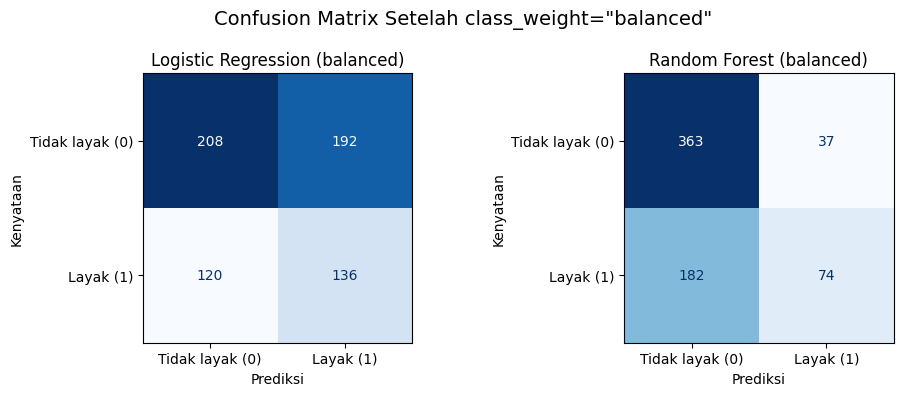

In [111]:
# Confusion matrix setelah class_weight="balanced"
fig, sumbu = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Confusion Matrix Setelah class_weight="balanced"', fontsize=14)

for ax, (nama, prediksi) in zip(sumbu, prediksi_seimbang.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_uji, prediksi,
        display_labels=["Tidak layak (0)", "Layak (1)"],
        cmap="Blues", colorbar=False, ax=ax
    )
    ax.set_title(nama)
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Kenyataan")

plt.tight_layout()
plt.show()

**Catatan Hasil Penanganan Ketidakseimbangan Kelas**

- **Logistic Regression:** setelah `class_weight="balanced"`, recall naik dari 0% menjadi 53,1% dan F1-score dari 0 menjadi 46,6%. Model kini benar-benar memprediksi kelas layak minum (136 dari 256 sampel berhasil ditemukan). Namun akurasi turun dari 61% menjadi 52,4%, dan 192 sampel air tidak layak salah diprediksi layak.
- **ROC-AUC Logistic Regression hampir tidak berubah** (0,548 menjadi 0,547). Artinya kemampuan model membedakan kedua kelas tetap lemah. Pembobotan hanya menggeser keseimbangan antara jenis kesalahan, bukan membuat model lebih pintar.
- **Random Forest:** hampir tidak ada perubahan (F1-score 41,4% menjadi 40,3%, recall 30,5% menjadi 28,9%). Kemungkinan penyebabnya, pohon yang tumbuh penuh sudah menghafal data latih sehingga pembobotan tidak banyak berpengaruh. Masalah overfitting ini akan ditangani pada bagian tuning hyperparameter.
- **Perbandingan sementara:** Logistic Regression (balanced) lebih banyak menemukan air layak, tetapi sering salah menyatakan air tidak layak sebagai layak. Random Forest lebih berhati-hati (precision 66,7%), tetapi melewatkan banyak air yang sebenarnya layak.

# FITUR PALING BERPENGARUH

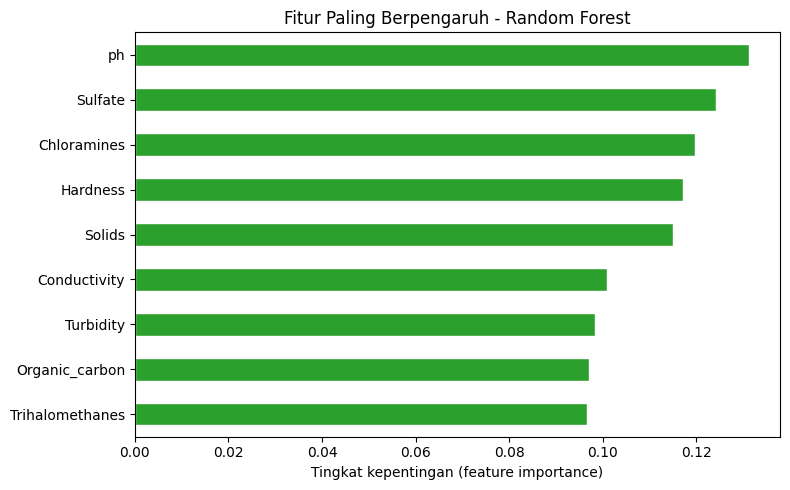

,0
ph,0.131
Sulfate,0.124
Chloramines,0.120
Hardness,0.117
Solids,0.115
Conductivity,0.101
Turbidity,0.098
Organic_carbon,0.097
Trihalomethanes,0.097


In [112]:
# Fitur paling berpengaruh pada Random Forest
pentingnya_rf = pd.Series(
    model_rf_seimbang.feature_importances_,
    index=X_latih_std.columns
).sort_values()

plt.figure(figsize=(8, 5))
pentingnya_rf.plot(kind="barh", color="tab:green", edgecolor="white")
plt.title("Fitur Paling Berpengaruh - Random Forest")
plt.xlabel("Tingkat kepentingan (feature importance)")
plt.tight_layout()
plt.show()

# Tampilkan angkanya, urut dari yang terbesar
pentingnya_rf.sort_values(ascending=False).round(3)

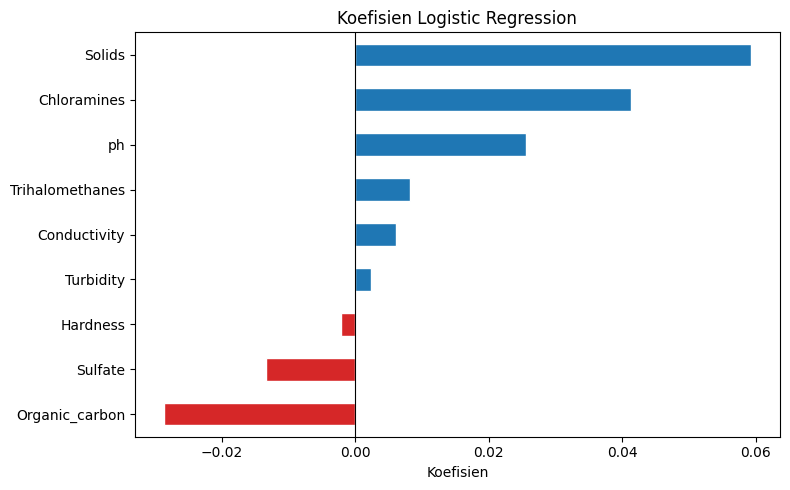

,0
Solids,0.059
Chloramines,0.041
Organic_carbon,-0.029
ph,0.026
Sulfate,-0.013
Trihalomethanes,0.008
Conductivity,0.006
Turbidity,0.002
Hardness,-0.002


In [113]:
# Koefisien Logistic Regression (biru = menaikkan peluang layak, merah = menurunkan)
koefisien_lr = pd.Series(
    model_lr_seimbang.coef_[0],
    index=X_latih_std.columns
).sort_values()

warna = ["tab:red" if k < 0 else "tab:blue" for k in koefisien_lr]

plt.figure(figsize=(8, 5))
koefisien_lr.plot(kind="barh", color=warna, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Koefisien Logistic Regression")
plt.xlabel("Koefisien")
plt.tight_layout()
plt.show()

# Tampilkan angkanya, urut dari pengaruh terbesar
koefisien_lr.sort_values(key=abs, ascending=False).round(3)

**Catatan Hasil Analisis Fitur**

- **Random Forest:** tiga fitur teratas adalah ph (0,131), Sulfate (0,124), dan Chloramines (0,120). Namun selisihnya dengan fitur terendah (0,097) sangat kecil. Seluruh fitur berada di kisaran 0,097-0,131, mendekati pembagian rata (1/9 ≈ 0,111), jadi tidak ada fitur yang dominan.
- **Logistic Regression:** koefisien terbesar adalah Solids (+0,059) dan Chloramines (+0,041), sedangkan Organic_carbon bernilai negatif (-0,029). Semua koefisien sangat kecil (di bawah 0,06), artinya tidak ada fitur yang berpengaruh kuat secara linear.
- **Kedua model tidak sepakat soal urutan teratas** (Random Forest: ph; Logistic Regression: Solids). Hasil ini sejalan dengan heatmap korelasi sebelumnya, yang menunjukkan hubungan tiap fitur dengan Potability sangat lemah.
- **Kesimpulan sementara:** pada dataset ini, kelayakan air tidak ditentukan oleh satu parameter saja, dan ini menjelaskan mengapa performa kedua model terbatas. Arah koefisien (misalnya Solids yang positif) tidak boleh dianggap sebagai hubungan sebab-akibat nyata karena nilainya sangat kecil.

# PERBANDINGAN MODEL

Bagian ini membandingkan model akhir pada data uji: Dummy sebagai pembanding, Logistic Regression (class_weight balanced), dan Random Forest (class_weight balanced). Hasilnya dipakai untuk memilih model yang digunakan pada tahap inference.

In [114]:
# Tabel perbandingan model akhir pada data uji
model_final = {
    "Dummy (pembanding)": model_dummy,
    "Logistic Regression": model_lr_seimbang,
    "Random Forest": model_rf_seimbang,
}

prediksi_final = {n: m.predict(X_uji_std) for n, m in model_final.items()}

hasil_final = pd.DataFrame({
    "Akurasi": {n: accuracy_score(y_uji, p) for n, p in prediksi_final.items()},
    "Precision": {n: precision_score(y_uji, p, zero_division=0) for n, p in prediksi_final.items()},
    "Recall": {n: recall_score(y_uji, p) for n, p in prediksi_final.items()},
    "F1-score": {n: f1_score(y_uji, p) for n, p in prediksi_final.items()},
    "ROC-AUC": {n: roc_auc_score(y_uji, m.predict_proba(X_uji_std)[:, 1]) for n, m in model_final.items()},
}).round(3)

hasil_final

,Akurasi,Precision,Recall,F1-score,ROC-AUC
Dummy (pembanding),0.610,0.000,0.000,0.000,0.500
Logistic Regression,0.524,0.415,0.531,0.466,0.547
Random Forest,0.666,0.667,0.289,0.403,0.655


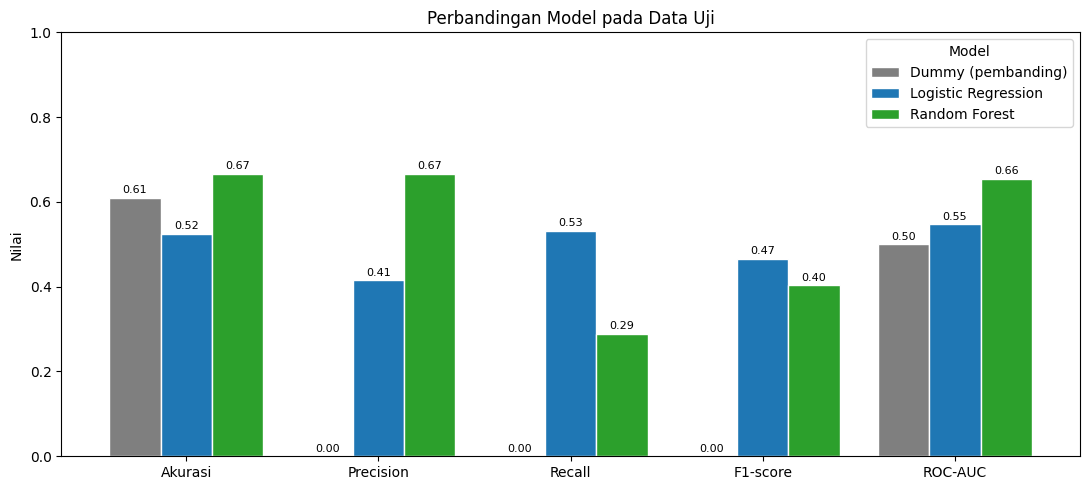

In [115]:
# Grafik perbandingan metrik tiap model
ax = hasil_final.T.plot(
    kind="bar", figsize=(11, 5), width=0.8,
    color=["tab:gray", "tab:blue", "tab:green"], edgecolor="white"
)

for wadah in ax.containers:
    ax.bar_label(wadah, fmt="%.2f", fontsize=8, padding=2)

plt.title("Perbandingan Model pada Data Uji")
plt.ylabel("Nilai")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model", loc="upper right")
plt.tight_layout()
plt.show()

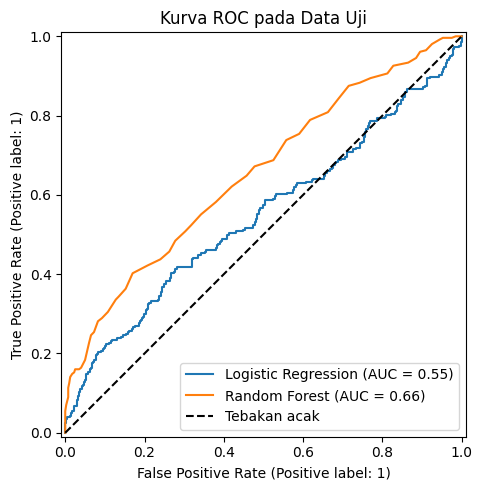

In [116]:
# Kurva ROC: semakin jauh di atas garis putus-putus, semakin baik
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))

for nama in ["Logistic Regression", "Random Forest"]:
    RocCurveDisplay.from_estimator(model_final[nama], X_uji_std, y_uji, name=nama, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Tebakan acak")
ax.set_title("Kurva ROC pada Data Uji")
ax.legend()
plt.tight_layout()
plt.show()

**Catatan Hasil Perbandingan Model**

- **Random Forest** unggul pada akurasi (66,6% vs 52,4%), precision (66,7% vs 41,5%), dan ROC-AUC (0,655 vs 0,547).
- **Logistic Regression** unggul pada recall (53,1% vs 28,9%) dan F1-score (46,6% vs 40,3%), artinya lebih banyak menemukan air layak minum.
- **Kurva ROC:** kurva Logistic Regression hampir berimpit dengan garis tebakan acak, sedangkan kurva Random Forest berada di atas garis tersebut hampir di seluruh titik. Ini menunjukkan Random Forest lebih mampu membedakan kedua kelas.
- **Risiko kesalahan:** Logistic Regression salah memprediksi 192 sampel air tidak layak sebagai layak (48% dari seluruh air tidak layak), sedangkan Random Forest hanya 37 sampel (9,3%). Pada kasus air minum, kesalahan jenis ini paling berbahaya.
- **Model terpilih: Random Forest (balanced)**, karena lebih sedikit salah menyatakan air tidak layak sebagai layak, dan kemampuan membedakan kelasnya lebih baik. Keterbatasannya, recall masih rendah (182 sampel air layak terlewat) dan performa keseluruhan masih terbatas.

# INFERENCE

In [117]:
# Fungsi untuk memprediksi satu sampel air baru
def prediksi_air(sampel, model):
    # Susun data dengan urutan kolom yang sama seperti data latih
    data_baru = pd.DataFrame([sampel], columns=X_latih.columns).astype(float)

    # Isi nilai kosong dengan median data latih
    data_baru = data_baru.fillna(median_latih)

    # Standarisasi dengan scaler data latih
    data_baru_std = pd.DataFrame(standarisasi.transform(data_baru), columns=data_baru.columns)

    # Prediksi kelas dan peluang layak minum
    kelas = model.predict(data_baru_std)[0]
    peluang = model.predict_proba(data_baru_std)[0, 1]
    label = "Layak minum" if kelas == 1 else "Tidak layak minum"
    return label, peluang

In [118]:
# Dua contoh sampel air baru (nilai dibuat sebagai contoh)
sampel_a = {
    "ph": 7.0, "Hardness": 196.0, "Solids": 20000.0, "Chloramines": 7.1,
    "Sulfate": 333.0, "Conductivity": 420.0, "Organic_carbon": 14.2,
    "Trihalomethanes": 66.0, "Turbidity": 4.0,
}

# Sampel B: nilai Sulfate kosong (None), akan diisi median otomatis
sampel_b = {
    "ph": 8.5, "Hardness": 180.0, "Solids": 35000.0, "Chloramines": 9.0,
    "Sulfate": None, "Conductivity": 500.0, "Organic_carbon": 12.0,
    "Trihalomethanes": 80.0, "Turbidity": 3.2,
}

for nama, sampel in [("Sampel A", sampel_a), ("Sampel B (Sulfate kosong)", sampel_b)]:
    label, peluang = prediksi_air(sampel, model_rf_seimbang)
    print(f"{nama:28s} -> {label:18s} | peluang layak: {peluang * 100:.1f}%")

Sampel A                     -> Tidak layak minum  | peluang layak: 22.0%
Sampel B (Sulfate kosong)    -> Layak minum        | peluang layak: 68.0%


In [119]:
# Cek fungsi pada 8 sampel pertama data uji (data asli, sebelum nilai kosong diisi)
sampel_uji = df.loc[X_uji.index[:8]]

baris = []
for _, r in sampel_uji.iterrows():
    label, peluang = prediksi_air(r.drop("Potability").to_dict(), model_rf_seimbang)
    baris.append({
        "Kenyataan": "Layak minum" if r["Potability"] == 1 else "Tidak layak minum",
        "Prediksi": label,
        "Peluang layak (%)": round(peluang * 100, 1),
    })

tabel_uji = pd.DataFrame(baris)
tabel_uji["Benar?"] = (tabel_uji["Kenyataan"] == tabel_uji["Prediksi"]).map({True: "Ya", False: "Tidak"})
tabel_uji

,Kenyataan,Prediksi,Peluang layak (%),Benar?
0,Layak minum,Tidak layak minum,34.0,Tidak
1,Tidak layak minum,Tidak layak minum,28.0,Ya
2,Tidak layak minum,Tidak layak minum,40.0,Ya
3,Tidak layak minum,Tidak layak minum,32.0,Ya
4,Tidak layak minum,Tidak layak minum,22.0,Ya
5,Tidak layak minum,Tidak layak minum,16.0,Ya
6,Tidak layak minum,Tidak layak minum,30.0,Ya
7,Tidak layak minum,Tidak layak minum,31.0,Ya


# KESIMPULAN

**Ringkasan Proyek**

Proyek ini memprediksi kelayakan air minum (Potability) dari 9 parameter kualitas air pada 3.276 sampel, dengan kelas tidak seimbang (61% tidak layak, 39% layak). Data dibagi 80% latih dan 20% uji secara stratified. Nilai kosong (ph, Sulfate, Trihalomethanes) diisi median data latih, lalu fitur distandarisasi. Dua algoritma dibandingkan: Logistic Regression dan Random Forest, dengan Dummy sebagai pembanding.

**Temuan Utama**

1. **Akurasi saja menyesatkan.** Model Dummy yang selalu menebak "tidak layak" sudah mendapat akurasi 61%. Logistic Regression bawaan bahkan sama persis dengan Dummy (recall 0%).
2. **Pembobotan kelas diperlukan.** Dengan `class_weight="balanced"`, Logistic Regression mulai mengenali air layak minum (recall 53,1%, F1-score 46,6%). Pada Random Forest, pembobotan hampir tidak mengubah hasil.
3. **Random Forest (balanced) dipilih sebagai model terbaik.** Akurasi 66,6%, precision 66,7%, dan ROC-AUC 0,655, dibanding Logistic Regression (balanced) dengan akurasi 52,4%, precision 41,5%, dan ROC-AUC 0,547. Random Forest hanya salah menyatakan 37 sampel air tidak layak sebagai layak, sedangkan Logistic Regression 192 sampel. Kesalahan jenis ini paling berbahaya pada air minum.
4. **Tidak ada fitur yang dominan.** Feature importance Random Forest tersebar merata (0,097-0,131) dan koefisien Logistic Regression sangat kecil (di bawah 0,06). Ini sejalan dengan heatmap korelasi yang menunjukkan hubungan tiap fitur dengan target sangat lemah.

**Keterbatasan**

- Performa model masih rendah. Random Forest hanya menemukan 28,9% air layak minum (recall), dan ROC-AUC Logistic Regression mendekati tebakan acak.
- Random Forest mengalami overfitting (pada pengaturan bawaan: akurasi latih 100%, uji 66,3%).
- Evaluasi memakai satu kali pembagian data, dan 24% nilai Sulfate diisi dengan median.
- Hasil prediksi tidak boleh dipakai untuk menentukan air aman diminum. Uji laboratorium tetap diperlukan.

**Saran Pengembangan**

- Tuning hyperparameter (misalnya `min_samples_leaf` pada Random Forest) untuk mengurangi overfitting, dan cross-validation agar evaluasi lebih stabil.
- Cara lain menangani ketidakseimbangan kelas: menggeser threshold prediksi, undersampling, atau SMOTE.
- Imputasi yang lebih baik daripada median, serta mencoba algoritma lain seperti Gradient Boosting.
- Menambah data atau parameter lain, karena 9 parameter yang ada belum cukup menjelaskan kelayakan air.